In [1]:
%pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../data/online_retail_II.csv')

# Data cleaning steps
## 1. Understand the data

> ```python
> df.head()
> df.info()
> df.describe()
> df.shape
> ```

---

## 2. Handle missing values

**Detect**

> ```python
> df.isnull().sum()
> ```

**Drop**

> ```python
> df.dropna()                      # drop rows
> df.dropna(axis=1)                # drop columns
> ```

**Impute**

> ```python
> df["age"].fillna(df["age"].mean(), inplace=True)
> df["city"].fillna(df["city"].mode()[0], inplace=True)
> ```

**Sklearn imputer**

> ```python
> from sklearn.impute import SimpleImputer
> 
> imputer = SimpleImputer(strategy="median")
> df[["salary"]] = imputer.fit_transform(df[["salary"]])
> ```

---

## 3. Remove duplicates

> ```python
> df.duplicated().sum()
> df = df.drop_duplicates()
> ```

---

## 4. Fix data types

> ```python
> df["age"] = df["age"].astype(int)
> df["date"] = pd.to_datetime(df["date"])
> ```

---

## 5. Handle inconsistent values

> ```python
> df["city"] = df["city"].str.lower().str.strip()
> 
> df["city"] = df["city"].replace({
>     "ny": "new york",
>     "nyc": "new york"
> })
> ```

---

**Capping**

> ```python
> df["income"] = df["income"].clip(lower=0, upper=200000)
> ```

---

## 6. Feature engineering

Cleaning alone is not enough.

Examples:

* Total transaction value
* RFM features
* Time-based features

```python
df["TotalAmount"] = df["Quantity"] * df["Price"]
```

This is a **must-have step** in ML pipelines.

---

## 7. Handle skew / transformation

Even if you skip “outlier handling”, you should:

* Log-transform
* Use robust scaling

```python
df["income"] = np.log1p(df["income"])
```

(Or later at feature level.)

---

## 8. Feature scaling

**Standardization**

> ```python
> from sklearn.preprocessing import StandardScaler
> 
> scaler = StandardScaler()
> df[["age", "income"]] = scaler.fit_transform(df[["age", "income"]])
> ```

**Normalization**

> ```python
> from sklearn.preprocessing import MinMaxScaler
> 
> scaler = MinMaxScaler()
> df[["age", "income"]] = scaler.fit_transform(df[["age", "income"]])
> ```

# Understand Data

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [8]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [9]:
df.shape

(1067371, 8)

# Handling Missing Values

In [10]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

I don't need the description so I am going to drop description column.

For customer segmentation and churn analysis, I removed transactions with missing Customer ID because churn and behavioral metrics require customer-level tracking. Anonymous purchases cannot be reliably modeled.

In [11]:
df = df.drop(columns="Description")

In [12]:
df = df.dropna(subset=["Customer ID"])

In [13]:
df.isnull().sum()

Invoice        0
StockCode      0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [14]:
df.shape

(824364, 7)

# Remove duplicates

If invoice, product (StockCode), quantity, and timestamp (InvoiceDate) are identical, I treat the row as a duplicate because it represents the same line item being recorded more than once.

In [15]:
df.duplicated(subset=["Invoice", "StockCode", "Quantity", "InvoiceDate"]).sum()

np.int64(26562)

In [16]:
df = df.drop_duplicates(
    subset=["Invoice", "StockCode", "Quantity", "InvoiceDate"],
    keep="first"
)


In [17]:
df.shape

(797802, 7)

# Fix data types

In [18]:
df.dtypes

Invoice            str
StockCode          str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

Let's converted date fields to datetime and treated identifiers as categorical variables to avoid misleading numerical operations.

In [19]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [20]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [21]:
df.dtypes

Invoice                   str
StockCode                 str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [22]:
df["Customer ID"] = df["Customer ID"].astype("int").astype("str")

In [23]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [24]:
df["Country"] = df["Country"].astype("category")

In [25]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [26]:
df.dtypes

Invoice                   str
StockCode                 str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID               str
Country              category
dtype: object

# Handle Inconsistent Values

In [27]:
df["Country"].value_counts()

Country
United Kingdom          716048
Germany                  17335
EIRE                     16014
France                   13897
Netherlands               5137
Spain                     3754
Belgium                   3110
Switzerland               3058
Portugal                  2414
Australia                 1890
Channel Islands           1646
Italy                     1507
Sweden                    1343
Norway                    1304
Cyprus                    1157
Finland                   1049
Austria                    938
Denmark                    797
Greece                     663
Japan                      565
USA                        535
Poland                     527
Unspecified                521
United Arab Emirates       386
Singapore                  338
Israel                     321
Malta                      299
Canada                     228
Iceland                    222
Lithuania                  154
RSA                        123
Brazil                      94


No extra spaces, different casing, same country misspelled found in country name.

In [28]:
df[df["Price"] <= 0]

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,12,2009-12-02 13:34:00,0.0,16126,United Kingdom
6781,489998,48185,2,2009-12-03 11:19:00,0.0,15658,United Kingdom
16107,490727,M,1,2009-12-07 16:38:00,0.0,17231,United Kingdom
18738,490961,22065,1,2009-12-08 15:25:00,0.0,14108,United Kingdom
18739,490961,22142,12,2009-12-08 15:25:00,0.0,14108,United Kingdom
...,...,...,...,...,...,...,...
979925,575579,22089,24,2011-11-10 11:49:00,0.0,13081,United Kingdom
1004540,577129,22464,4,2011-11-17 19:52:00,0.0,15602,United Kingdom
1005014,577168,M,1,2011-11-18 10:42:00,0.0,12603,Germany
1011446,577696,M,1,2011-11-21 11:57:00,0.0,16406,United Kingdom


Negative or zero price is free item, correction, or error. So we will remove it.

In [29]:
df = df[df["Price"] > 0]

In [30]:
df[df["Quantity"] <= 0]

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,-12,2009-12-01 10:33:00,2.95,16321,Australia
...,...,...,...,...,...,...,...
1065910,C581490,23144,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
1067002,C581499,M,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
1067176,C581568,21258,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
1067177,C581569,84978,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


Negative or zero quantity means item is return, error, or correction

In [31]:
df = df[df["Quantity"] > 0]

In [32]:
df["StockCode"].unique()[:20]

<StringArray>
[ '85048', '79323P', '79323W',  '22041',  '21232',  '22064',  '21871',
  '21523',  '22350',  '22349',  '22195',  '22353', '48173C',  '21755',
  '21754',  '84879',  '22119',  '22142',  '22296',  '22295']
Length: 20, dtype: str

I found that in stock code post mean postage, D mean discount, M mean manual adjustment so they need to remove.

In [33]:
df = df[~df["StockCode"].isin(['POST', 'D', 'M'])]

In invoice start with C are cancelled items. So need to remove.

In [34]:
df = df[~df["Invoice"].str.startswith('C')]

# Feature engineering

Add new column Total Amount.

In [35]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

Reference Date one day after the last transaction

In [36]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

RFM table

In [37]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]


In [38]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,1658.40
12349,19,3,3678.69
12350,310,1,294.40


In [39]:
rfm.describe()

,Recency,Frequency,Monetary
count,5862.000000,5862.000000,5862.000000
mean,200.867793,6.256397,2916.603845
std,209.095351,12.807525,14336.064571
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,338.725000
50%,95.500000,3.000000,855.220000
75%,379.000000,7.000000,2237.032500
max,739.000000,379.000000,580987.040000


In [40]:
rfm.shape

(5862, 3)

# Handle skew & transform RFM features

Check skewness

In [41]:
rfm.skew()

Recency       0.891494
Frequency    12.160103
Monetary     25.275094
dtype: float64

Apply log transformation

In [42]:
rfm_transformed = rfm.copy()

rfm_transformed["Recency"] = np.log1p(rfm_transformed["Recency"])
rfm_transformed["Frequency"] = np.log1p(rfm_transformed["Frequency"])
rfm_transformed["Monetary"] = np.log1p(rfm_transformed["Monetary"])

In [43]:
rfm_transformed.describe()

,Recency,Frequency,Monetary
count,5862.000000,5862.000000,5862.000000
mean,4.451360,1.546736,6.805091
std,1.559345,0.808267,1.383228
min,0.693147,0.693147,1.373716
25%,3.295837,0.693147,5.828136
50%,4.569530,1.386294,6.752527
75%,5.940171,2.079442,7.713352
max,6.606650,5.940171,13.272485


In [44]:
rfm_transformed.skew()

Recency     -0.487178
Frequency    1.002850
Monetary     0.267400
dtype: float64

# Feature Scaling

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_transformed[["Recency", "Frequency", "Monetary"]]
)

In [46]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm_transformed.index
)

In [47]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.862000e+03,5.862000e+03,5.862000e+03
mean,5.212101e-17,8.727239e-17,-3.587865e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-2.410328e+00,-1.056164e+00,-3.926931e+00
25%,-7.410944e-01,-1.056164e+00,-7.063467e-01
50%,7.578772e-02,-1.985183e-01,-3.800419e-02
75%,9.548480e-01,6.591275e-01,6.566805e-01
max,1.382294e+00,5.436090e+00,4.675981e+00


After log-transforming RFM features, I applied standardization so that recency, frequency, and monetary contributed equally to distance-based clustering

## 🔹 PHASE 1: Customer Segmentation (Unsupervised)

### 1️⃣ K-Means clustering (primary)

* Run K-Means for K = 2…10
* Compute:

  * Inertia (Elbow method)
  * Silhouette score

---

### 2️⃣ Select optimal K

* Choose K with:

  * Clear elbow
  * Highest / stable silhouette score

---

### 3️⃣ Train final K-Means model

* Fit K-Means with chosen K
* Assign cluster labels to customers

---

### 4️⃣ Evaluate K-Means clustering

* Silhouette score
* Cluster size distribution

---

### 5️⃣ Interpret clusters (business validation)

* Compute mean RFM per cluster
* Label clusters (e.g., Loyal, At-Risk, Churned)

---

### 6️⃣ Hierarchical clustering (validation)

* Fit Agglomerative clustering with same K
* Compare:

  * Silhouette score
  * Cluster structure vs K-Means

---
## 🔹 PHASE 2: Churn Definition

### 8️⃣ Define churn rule

* Example: No purchase in last **180 days**

---

### 9️⃣ Create churn label

* Binary target variable (0 = active, 1 = churned)

---

## 🔹 PHASE 3: Churn Modeling (Supervised)

### 🔟 Prepare churn dataset

* Features: `rfm_scaled`
* Target: churn label

---

### 1️⃣1️⃣ Train Logistic Regression (baseline)

* Fit model
* Predict churn probability

---

### 1️⃣2️⃣ Evaluate Logistic Regression

* ROC-AUC
* Recall (churn class)
* Confusion matrix

---

### 1️⃣3️⃣ Train Random Forest

* Fit model
* Predict churn probability

---

### 1️⃣4️⃣ Evaluate Random Forest

* ROC-AUC
* Recall
* Feature importance

---

### 1️⃣5️⃣ Train XGBoost

* Fit model
* Predict churn probability

---

### 1️⃣6️⃣ Evaluate XGBoost

* ROC-AUC
* Recall
* Precision-Recall tradeoff

---

### 1️⃣8️⃣ Select final churn model

* Choose based on:

  * Business goal (catch churners vs false alarms)
  * Model complexity

---

## 🔹 PHASE 4: Combined Insights

### 1️⃣9️⃣ Combine segmentation + churn

* Identify **high-value customers at churn risk**

---

### 2️⃣0️⃣ Business recommendations

* Retention strategies per segment

---



# Customer Segmentation (Unsupervised)

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## Elbow Method

In [49]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

## Elbow Plot

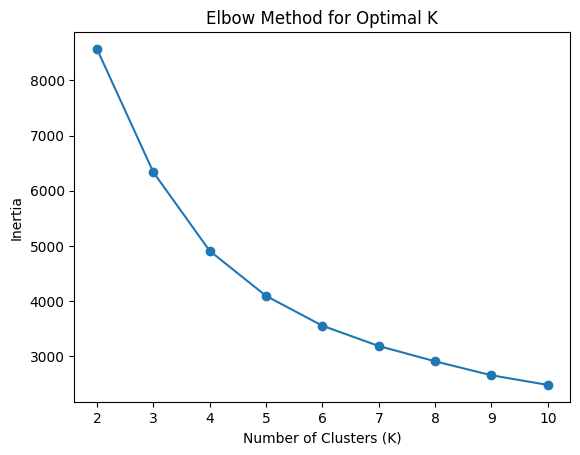

In [50]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

## Silhouette Score

In [51]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores


[0.43817149977875486,
 0.3476384276338038,
 0.36545457400635817,
 0.34265617923373387,
 0.3315992455763836,
 0.30248107310433975,
 0.2913852185625936,
 0.28782041416114584,
 0.2935999250284384]

## Silhouette Plot

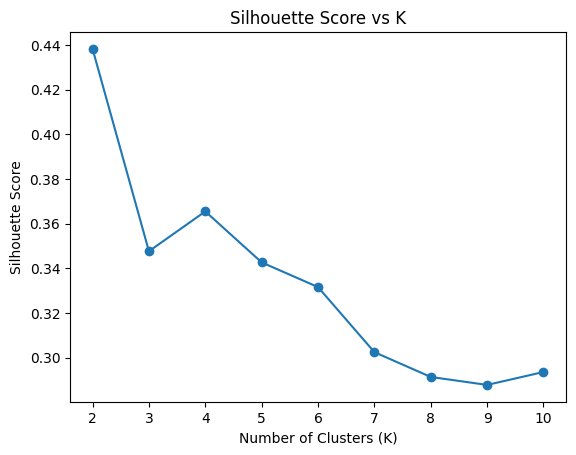

In [52]:
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

## Combine results for comparison

In [53]:
k_results = pd.DataFrame({
    "K": list(range(2, 11)),
    "Inertia": inertia,
    "Silhouette": silhouette_scores
})

k_results

,K,Inertia,Silhouette
0,2,8571.615547,0.438171
1,3,6336.071964,0.347638
2,4,4907.921481,0.365455
3,5,4090.853507,0.342656
4,6,3550.093204,0.331599
5,7,3182.141582,0.302481
6,8,2903.931648,0.291385
7,9,2650.875593,0.287820
8,10,2476.108757,0.293600


### 1️⃣ Silhouette score

* **Best silhouette = K = 2 (0.438)**
* But K=2 is usually **too coarse** for business segmentation:

  * “Good customers” vs “everyone else”
  * Not actionable

---

### 2️⃣ Inertia (Elbow method)

* Large drops from:

  * K=2 → 3
  * K=3 → 4
* After **K ≈ 4**, improvement slows noticeably

👉 This suggests an **elbow around K = 4**

---

### 3️⃣ Trade-off: separation vs usefulness

| K     | Interpretation                             |
| ----- | ------------------------------------------ |
| 2     | Best mathematically, poor business insight |
| 3     | Simpler, but silhouette drops sharply      |
| **4** | ✅ Best balance                             |
| 5+    | Over-fragmentation, weaker separation      |

---

## ✅ Final decision: **K = 4**

### Why K = 4 is the correct choice

* Reasonably high silhouette (**0.365**, second best)
* Clear elbow in inertia
* Produces **interpretable customer segments**
* Very common and accepted in RFM-based retail segmentation


In [54]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(rfm_scaled)

In [55]:
rfm["Cluster"] = cluster_labels

In [56]:
rfm["Cluster"].value_counts()

Cluster
0    1985
2    1462
3    1247
1    1168
Name: count, dtype: int64

In [57]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,394.191940,1.381864,319.146323
1,27.624144,19.388699,10767.223542
2,224.045144,5.137483,1941.659779
3,28.225341,3.027265,841.060619


In [58]:
rfm["Segment"] = rfm["Cluster"].map({
    0: "Lost Customers",
    1: "VIP Customers",
    2: "At-Risk Customers",
    3: "Active Regular Customers"
})

In [59]:
rfm["Segment"].head()

Customer ID
12346               VIP Customers
12347               VIP Customers
12348           At-Risk Customers
12349    Active Regular Customers
12350              Lost Customers
Name: Segment, dtype: str

## Cluster Visualization

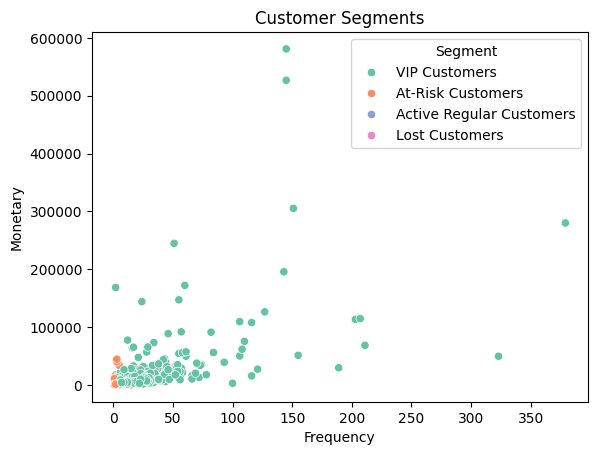

In [60]:
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="Set2"
)

plt.title("Customer Segments")
plt.show()

### Hierarchical Clustering

In [61]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4)
hc_labels = hc.fit_predict(rfm_scaled)

In [62]:
hc_silhouette = silhouette_score(rfm_scaled, hc_labels)
hc_silhouette

0.2904378112700669

In [63]:
kmeans_silhouette = silhouette_score(rfm_scaled, cluster_labels)
kmeans_silhouette

0.36545457400635817

In [64]:
kmeans_silhouette - hc_silhouette

0.07501676273629126

#### 🔎 Interpretation
### 1️⃣ K-Means is clearly better

- Higher silhouette score

- Better cluster separation

- More compact structure

- A difference of 0.07+ is meaningful in clustering.

### 2️⃣ What this tells us

- Data likely forms compact, spherical clusters

- Hierarchical clustering struggles a bit more with this structure

So the conclusion is:

✅ K-Means is the better segmentation model

---

## Define churn with 180 days

In [65]:
rfm["Churn"] = (rfm["Recency"] > 180).astype(int)

In [66]:
rfm["Churn"].value_counts()

Churn
0    3473
1    2389
Name: count, dtype: int64

In [67]:
rfm["Churn"].value_counts(normalize=True) * 100

Churn
0    59.245991
1    40.754009
Name: proportion, dtype: float64

### Prepare modeling dataset

In [68]:
# Use the **unscaled** RFM features for churn modeling.
# We'll perform scaling after splitting the data so that the scaler

# is fit only on the training set (preventing test-set leakage).y = rfm["Churn"]
X = rfm_transformed[["Frequency", "Monetary"]]
y = rfm["Churn"]

### Train-Test Split

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split before scaling to avoid any information from the test set
# influencing the training data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# now fit scaler on training data only and apply to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert back to DataFrames and overwrite the originals so that the
# downstream modeling code can remain unchanged
X_train = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
)
X_test = pd.DataFrame(
    X_test_scaled, columns=X_test.columns, index=X_test.index
)


### 1️⃣ Logistic Regression (Baseline)

In [70]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [71]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred_lr))
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

roc_auc_lr, conf_matrix_lr

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       695
           1       0.65      0.65      0.65       478

    accuracy                           0.72      1173
   macro avg       0.71      0.71      0.71      1173
weighted avg       0.72      0.72      0.72      1173



(0.7845143132356038,
 array([[526, 169],
        [165, 313]]))

### 2️⃣ Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [73]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(classification_report(y_test, y_pred_rf))
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

roc_auc_rf, conf_matrix_rf

              precision    recall  f1-score   support

           0       0.70      0.68      0.69       695
           1       0.56      0.58      0.57       478

    accuracy                           0.64      1173
   macro avg       0.63      0.63      0.63      1173
weighted avg       0.65      0.64      0.64      1173



(0.6931459016886908,
 array([[475, 220],
        [199, 279]]))

In [74]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

Monetary     0.844307
Frequency    0.155693
dtype: float64

### 3️⃣ XGBoost

In [75]:
%pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [76]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

/Users/nikhildhole/github/retail-crunch-segmentation/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:49:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [77]:
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(classification_report(y_test, y_pred_xgb))
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

roc_auc_xgb, conf_matrix_xgb

              precision    recall  f1-score   support

           0       0.74      0.73      0.73       695
           1       0.61      0.64      0.63       478

    accuracy                           0.69      1173
   macro avg       0.68      0.68      0.68      1173
weighted avg       0.69      0.69      0.69      1173



(0.7565470636043465,
 array([[504, 191],
        [173, 305]]))

## Build a Comparison Table

In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, y_test, y_pred, y_prob):
    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Recall (Churn)": recall_score(y_test, y_pred),
        "Precision (Churn)": precision_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

In [79]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb))

comparison_df = pd.DataFrame(results)
comparison_df

,Model,ROC-AUC,Recall (Churn),Precision (Churn),F1-Score
0,Logistic Regression,0.784514,0.654812,0.649378,0.652083
1,Random Forest,0.693146,0.583682,0.559118,0.571136
2,XGBoost,0.756547,0.638075,0.614919,0.626283


# 🔎 Interpretation

## 1️⃣ Logistic Regression is the best overall

* Highest ROC-AUC (0.784)
* Highest Recall (0.655)
* Highest F1-score
* Very stable performance

This means:

* Best at ranking churners
* Balanced precision–recall
* Most reliable model

---

## 2️⃣ Random Forest underperformed

* Lower ROC-AUC
* Lower recall
* Likely overfitting small feature space (only 2 features)

Tree models shine when:

* Many nonlinear features
* Complex interactions

You only used:

* Frequency
* Monetary

So logistic regression naturally works better.

---

## 3️⃣ XGBoost is good, but not better than LR

* ROC-AUC = 0.756 (good)
* Recall slightly lower than LR
* More complex model

When performance gain is small:
👉 Simpler model wins.

---

# 🎯 Final Model Selection

## ✅ Final churn model: **Logistic Regression**

* Best ROC-AUC
* Best Recall
* Most interpretable
* Less overfitting risk
* Business-friendly

---
# Combined Insights

### Step 1: Add churn probability

In [80]:
rfm["Churn_Prob"] = lr.predict_proba(
    scaler.transform(rfm_transformed[["Frequency", "Monetary"]])
)[:, 1]

/Users/nikhildhole/github/retail-crunch-segmentation/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Step 2: Analyze by segment

In [81]:
rfm.groupby("Segment")[["Monetary", "Churn_Prob"]].mean()

,Monetary,Churn_Prob
Segment,,
Active Regular Customers,841.060619,0.454905
At-Risk Customers,1941.659779,0.291257
Lost Customers,319.146323,0.655438
VIP Customers,10767.223542,0.086177


# 🔎 Interpretation by Segment

---

## 🏆 1️⃣ VIP Customers

* 💰 Very high value (10,767)
* 📉 Very low churn risk (8.6%)

### Insight:

These are loyal, stable customers.

### Action:

* Loyalty rewards
* Early access offers
* Premium engagement
* Upsell / cross-sell

👉 Goal: **Maximize lifetime value**

---

## 🔵 2️⃣ Active Regular Customers

* 💰 Moderate value
* ⚠ Medium churn probability (~45%)

### Insight:

They are active but unstable.

### Action:

* Personalized recommendations
* Reminder emails
* Small discount incentives
* Engagement campaigns

👉 Goal: **Prevent migration to Lost segment**

---

## 🟠 3️⃣ At-Risk Customers

* 💰 High value (1,941)
* ⚠ Moderate churn probability (29%)

### Insight:

They spend well but engagement is weakening.

These are **strategic customers**.

### Action:

* Targeted retention campaigns
* Exclusive offers
* Feedback surveys
* Win-back campaigns

👉 Goal: **Protect valuable revenue**

---

## 🔴 4️⃣ Lost Customers

* 💰 Low value
* ❌ Highest churn risk (65%)

### Insight:

Low engagement, low revenue.

### Action:

* Low-cost reactivation emails
* Automated campaigns
* Limited incentives
* Do not overspend marketing budget

👉 Goal: **Cost-efficient recovery**

---
## Identify High-Value Customers at Risk

The real business gold is:

High Monetary + High Churn Probability

In [82]:
high_value_at_risk = rfm[
    (rfm["Monetary"] > rfm["Monetary"].quantile(0.75)) &
    (rfm["Churn_Prob"] > 0.5)
]

high_value_at_risk.head()

,Recency,Frequency,Monetary,Cluster,Segment,Churn,Churn_Prob
Customer ID,,,,,,,
12511,429,1,3084.020,2,At-Risk Customers,1,0.552413
12536,59,1,4279.710,2,At-Risk Customers,0,0.531642
12671,606,1,2622.481,2,At-Risk Customers,1,0.562626
12688,114,1,4873.810,2,At-Risk Customers,0,0.523367
12752,81,1,4366.780,2,At-Risk Customers,0,0.530361


### Executive-Level Summary
Segmentation identified four customer groups. VIP customers are highly valuable with low churn risk, while Lost customers have the highest churn probability but low revenue. The key business focus should be Active Regular and At-Risk customers, as they represent significant revenue with moderate churn probability.


### ✔ Data Cleaning

* Removed invalid transactions
* Removed cancellations
* Removed non-product codes
* Fixed data types
* Prevented leakage (very important)

### ✔ Feature Engineering

* Created RFM table
* Log transformed
* Scaled features

### ✔ Customer Segmentation

* Selected K via Elbow + Silhouette
* Validated with hierarchical clustering
* Interpreted clusters
* Assigned business segments

### ✔ Churn Modeling

* Defined churn rule
* Prevented target leakage
* Compared Logistic, RF, XGBoost
* Selected best model (Logistic Regression)

### ✔ Combined Insights

* Calculated churn probability
* Identified high-value churn-risk customers
* Proposed segment-level strategies